# Flight Delay Training Pipeline Walkthrough

This notebook shows the training pipeline step by step. It is meant for team members who want to understand what happens without reading all Python modules first.

Goal: classify the departure delay into four classes two hours before departure:

- `no_delay`: delay <= 15 minutes
- `small_delay`: 15 < delay <= 30 minutes
- `medium_delay`: 30 < delay <= 60 minutes
- `large_delay`: delay > 60 minutes


## 1. Setup

Run this notebook from the `pipeline/` folder.

In Colab, mount Drive and set `DATA_ROOT` below. If imports fail in Colab, install the needed packages once:

```python
%pip install pandas numpy scikit-learn pyarrow s3fs joblib
```


In [1]:
from pathlib import Path
import os
import sys
import pandas as pd
from dotenv import load_dotenv

# Make local imports work when the notebook is opened from another folder.
PIPELINE_DIR = Path.cwd()
if not (PIPELINE_DIR / 'loader.py').exists():
    PIPELINE_DIR = Path.cwd() / 'pipeline'

if str(PIPELINE_DIR) not in sys.path:
    sys.path.append(str(PIPELINE_DIR))

from loader import LoaderStorage
from targets import add_delay_class_target, DELAY_CLASS_ORDER
from split import chronological_train_val_test_split
from features import build_feature_matrix, fit_transform, transform, check_columns
from evaluate import evaluate_classifier, classification_report_frame, f1_macro_score, plotConfusionMatrix
from train import TrainingConfig, run_training


In [2]:
from models import make_model,make_neural_network_model, get_feature_importances, plot_feature_importances


## 2. Configuration

Only change this cell for normal usage.

Examples:

- Colab/Drive: `DATA_ROOT = "/content/drive/MyDrive/Datamining"`
- S3: `DATA_ROOT = "s3://data-mining"`
- Local folder: `DATA_ROOT = "."`


In [3]:
# Change these paths to your actual dataset location.
DATA_ROOT = "s3://data-mining"
INPUT_PATH = 'data/features/feature_engineered_more_weather.parquet'

# Column names used by the current pipeline.
DELAY_COLUMN = 'ArrDelayMinutes'
TIME_COLUMN = 'CRSDepDateTime_UTC'
TARGET_COLUMN = 'delay_class'

# Use a small sample while learning/debugging. Set to 1.0 for the final run.
SAMPLE_FRAC = 0.05

# Good first choices: 'dummy', 'logistic_regression', 'random_forest', 'hist_gradient_boosting'.
MODEL_NAME = 'xgboost'

OUTPUT_DIR = 'outputs/training_notebook'


## 3. Load The Data

`LoaderStorage` hides whether the file is loaded from local disk, Google Drive, or S3. The rest of the notebook can use the same code for all three.


In [4]:
storage = LoaderStorage(DATA_ROOT)

if INPUT_PATH.endswith('.parquet'):
    df = storage.read_parquet(INPUT_PATH)
elif INPUT_PATH.endswith('.csv'):
    df = storage.read_csv(INPUT_PATH)
else:
    raise ValueError('Use a .parquet or .csv dataset.')

if SAMPLE_FRAC < 1.0:
    df = df.sample(frac=SAMPLE_FRAC, random_state=42)

print(f'Rows: {len(df):,}')
print(f'Columns: {len(df.columns):,}')
df.head()


Rows: 202,139
Columns: 90


,Unnamed: 0,Year,Month,DayofMonth,DayOfWeek,Reporting_Airline,Origin,Dest,ArrDelayMinutes,CRSElapsedTime,...,hd_route_airline_arr_7d,hd_route_airline_arr_30d,origin_yesterday_delay,origin_lastweek_delay,dest_yesterday_delay,dest_lastweek_delay,airline_yesterday_delay,airline_lastweek_delay,global_yesterday_delay,global_lastweek_delay
2824382,268721,2015,6,25,4,DL,DTW,FLL,6.0,176.0,...,1.885714,5.241667,11.751553,18.096970,19.991736,25.483607,17.534435,14.828092,19.645054,25.652480
2618115,197352,2015,5,20,3,UA,SFO,JFK,0.0,337.0,...,35.153061,17.375714,15.232365,9.695473,12.624309,10.639785,11.748466,17.353488,15.133402,9.704926
1123153,65626,2014,8,11,1,B6,SFO,JFK,20.0,341.0,...,14.309524,20.405556,16.991935,24.996226,11.172414,11.954545,19.250000,16.481203,11.802652,18.977261
3088538,260210,2015,8,4,2,UA,SAN,IAH,11.0,191.0,...,22.685714,24.906667,9.751553,12.534591,15.614973,6.956757,21.635246,23.851675,12.704381,12.101104
2646493,101135,2015,5,26,2,WN,CLT,HOU,178.0,165.0,...,2.428571,14.600000,13.000000,8.558140,8.683333,14.050000,17.762048,20.879121,16.695405,15.133402


## 4. Create The Target Classes

The raw delay in minutes is converted into the four interval classes. After this step, the model predicts `delay_class`, not the exact number of minutes.


In [5]:
df = add_delay_class_target(
    df,
    delay_column=DELAY_COLUMN,
    target_column=TARGET_COLUMN,
)

# Show the class balance. This is important because large delays are usually rare.
class_distribution = (
    df[TARGET_COLUMN]
    .value_counts()
    .reindex(DELAY_CLASS_ORDER, fill_value=0)
    .to_frame(name='count')
)

class_distribution['share'] = class_distribution['count'] / len(df)
# expected amount in the test set (20% of the data)
class_distribution['expected_in_test'] = class_distribution['count'] * 0.15
display(class_distribution)

,count,share,expected_in_test
delay_class,,,
no_delay,162153,0.802186,24322.95
small_delay,15535,0.076853,2330.25
medium_delay,12492,0.061799,1873.80
large_delay,11959,0.059162,1793.85


In [6]:
# check if all expected Columsn are present, and what unexpected ones we have.
check_columns(df)
# drop the Unnamed:0 column
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

Info: The following columns are in the dataset but not recorded in the feature engineering lists: {'total_flights_in_hour_ARR', 'flights_departing_in_hour_ARR', 'Unnamed: 0', 'total_flights_in_hour_DEP', 'flights_arriving_in_hour_ARR', 'rhum_ARR', 'rhum', 'flights_arriving_in_hour_DEP', 'flights_departing_in_hour_DEP', 'information_hour_local', 'hd_ground_crew_carrier_3d'}


## 5. Chronological Train / Validation / Test Split

For a forecasting-like task, we should not randomly mix old and future flights. The model trains on older flights and is evaluated on later flights.

- Train: first 70% of time
- Validation: next 15%
- Test: final 15%


In [7]:
train_df, val_df, test_df = chronological_train_val_test_split(
    df,
    time_column=TIME_COLUMN,
)

print(f'Train rows:      {len(train_df):,}')
print(f'Validation rows: {len(val_df):,}')
print(f'Test rows:       {len(test_df):,}')

pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'start': [train_df[TIME_COLUMN].min(), val_df[TIME_COLUMN].min(), test_df[TIME_COLUMN].min()],
    'end': [train_df[TIME_COLUMN].max(), val_df[TIME_COLUMN].max(), test_df[TIME_COLUMN].max()],
    'rows': [len(train_df), len(val_df), len(test_df)],
})
# drop the time column to avoid data leakage. We will use it later to check the chronological order of the splits.
train_df = train_df.drop(columns=[TIME_COLUMN])
val_df = val_df.drop(columns=[TIME_COLUMN])
test_df = test_df.drop(columns=[TIME_COLUMN])

Train rows:      141,497
Validation rows: 30,321
Test rows:       30,321


## 6. Build Features

This step separates `X` and `y`:

- `X`: the input columns the model is allowed to use
- `y`: the delay class the model should learn to predict

The helper also drops obvious leakage columns like actual delay, actual departure time, actual arrival time, etc.


In [8]:
X_train, y_train = fit_transform(train_df, scale="minmax") # alternatively "standard"
X_val, y_val = transform(val_df)
X_test, y_test = transform(test_df)



print(f'Number of model features: {len(X_train.columns):,}')
X_train.head()


Info: The following columns are in the dataset but not recorded in the feature engineering lists: {'total_flights_in_hour_ARR', 'flights_departing_in_hour_ARR', 'total_flights_in_hour_DEP', 'flights_arriving_in_hour_ARR', 'rhum_ARR', 'rhum', 'flights_arriving_in_hour_DEP', 'flights_departing_in_hour_DEP', 'information_hour_local', 'hd_ground_crew_carrier_3d'}
Number of model features: 158


,Year,Month,DayofMonth,DayOfWeek,CRSElapsedTime,Distance,DistanceGroup,CRSDepDateTime,CRSArrDateTime,DayOfYear,...,Dest_ORD,Dest_PDX,Dest_PHL,Dest_PHX,Dest_SAN,Dest_SEA,Dest_SFO,Dest_SLC,Dest_STL,Dest_TPA
0,2014,1,1,3,239.0,0.267729,6,0.216179,0.342837,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2014,1,1,3,176.0,0.201512,5,0.247559,0.372045,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2014,1,1,3,195.0,0.210709,5,0.247559,0.385257,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2014,1,1,3,200.0,0.210300,5,0.261506,0.360918,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2014,1,1,3,170.0,0.131412,3,0.289400,0.367872,1,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
y_train.head()

0    0
1    0
2    0
3    0
4    0
Name: delay_class, dtype: int64

## 7. Train A Simple Baseline

Always train a baseline first. If a complex model does not beat this, something is wrong or the features are weak.


In [10]:
baseline = make_model('dummy')
baseline.fit(X_train, y_train)

baseline_metrics, baseline_predictions = evaluate_classifier(baseline, X_test, y_test)
display(pd.Series(baseline_metrics, name='baseline_validation_metrics'))

class_distribution = (
    y_train
    .value_counts()
    .to_frame(name='count')
)
display(class_distribution)

F1-macro: 0.2290


accuracy             0.844728
balanced_accuracy    0.250000
macro_f1             0.228957
weighted_f1          0.773627
Name: baseline_validation_metrics, dtype: float64

,count
delay_class,
0,111645
1,11614
2,9300
3,8938


In [11]:
# baseline = make_model('Baseline')
# baseline.fit(X_train, y_train)

# baseline_metrics, baseline_predictions = evaluate_classifier(baseline, X_test, y_test)
# pd.Series(baseline_metrics, name='baseline_validation_metrics')


## 8. Train The Selected Model

Now train the model chosen in the configuration cell. For large datasets, start with a small sample and only later set `SAMPLE_FRAC = 1.0`.


In [12]:
import inspect
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
import numpy as np



weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(weights))
class_weight_dict = {0: 0.25,
                     1: 0.75,
                     2: 1.0,
                     3: 1.25}
sample_weights = compute_sample_weight(class_weight=class_weight_dict, y=y_train)

model = make_model(MODEL_NAME)
# fit_model_with_class_weights(model, X_train, y_train)
model.fit(X_train, y_train,sample_weight=sample_weights)
val_metrics, val_predictions = evaluate_classifier(model, X_test, y_test)
pd.Series(val_metrics, name=f'{MODEL_NAME}_validation_metrics')


c:\miniconda3\envs\imgP\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:40:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


F1-macro: 0.3842


accuracy             0.844992
balanced_accuracy    0.367785
macro_f1             0.384207
weighted_f1          0.809448
Name: xgboost_validation_metrics, dtype: float64

In [13]:
# model = make_neural_network_model(input_shape=X_train.shape[1], num_classes=len(DELAY_CLASS_ORDER))
# # fit_model_with_class_weights(model, X_train, y_train)
# hist =model.fit(X_train, y_train, epochs=5, batch_size=256, validation_data=(X_val, y_val),sample_weight=sample_weights,shuffle=True)
# f1_macro = f1_macro_score(model, X_val, y_val)
# print(f"Validation f1-macro score: {f1_macro:.4f}")
# val_metrics, neuralNetwork_predictions = evaluate_classifier(model, X_test, y_test)
# pd.Series(val_metrics, name=f'NN_validation_metrics')

# # plot the training history
# import matplotlib.pyplot as plt
# fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# hist_df = pd.DataFrame(hist.history)
# axes[0].plot(hist.history["loss"], label="Training Loss")
# axes[0].plot(hist.history["val_loss"], label="Validation Loss")
# axes[0].set_xlabel("Epoch")
# axes[0].set_ylabel("Loss")
# axes[0].legend()



# axes[1].plot(hist.history["f1_score"], label="Training F1-Score")
# axes[1].plot(hist.history["val_f1_score"], label="Validation F1-Score")
# axes[1].set_xlabel("Epoch")
# axes[1].set_ylabel("F1-Score")
# axes[1].legend()

# axes[2].plot(hist.history["accuracy"], label="Training Accuracy")
# axes[2].plot(hist.history["val_accuracy"], label="Validation Accuracy")
# axes[2].set_xlabel("Epoch")
# axes[2].set_ylabel("Accuracy")
# axes[2].legend()
# plt.tight_layout()
# plt.show()

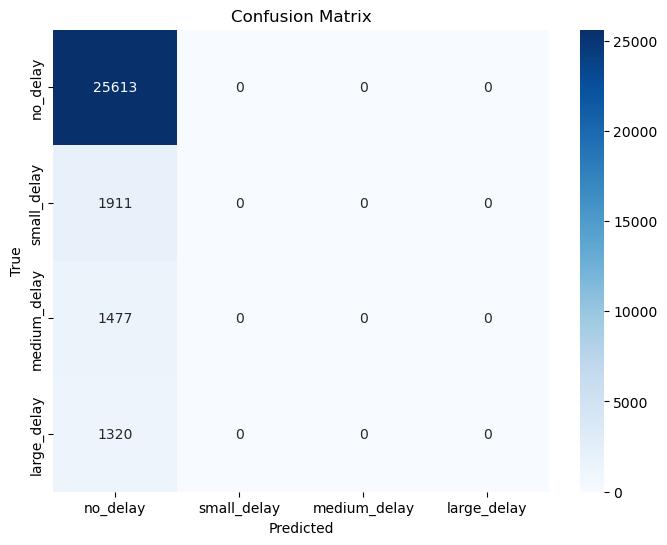

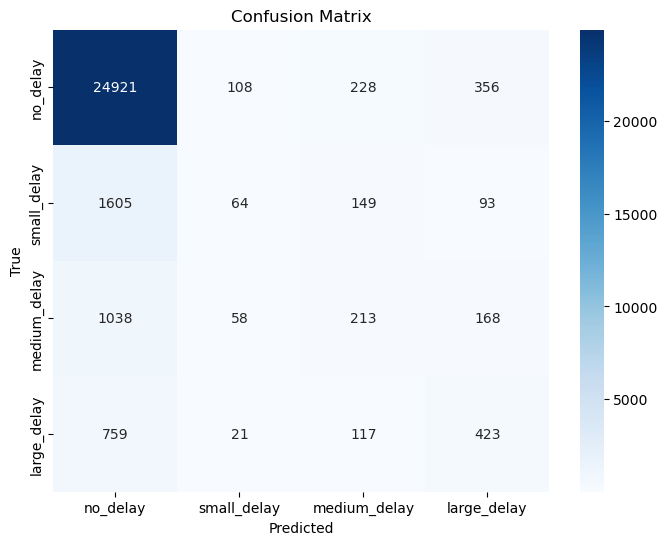

In [14]:
# plot baseline confusion matrix
plotConfusionMatrix(predictions=baseline_predictions, y_true=y_test)
plotConfusionMatrix(predictions=val_predictions, y_true=y_test)


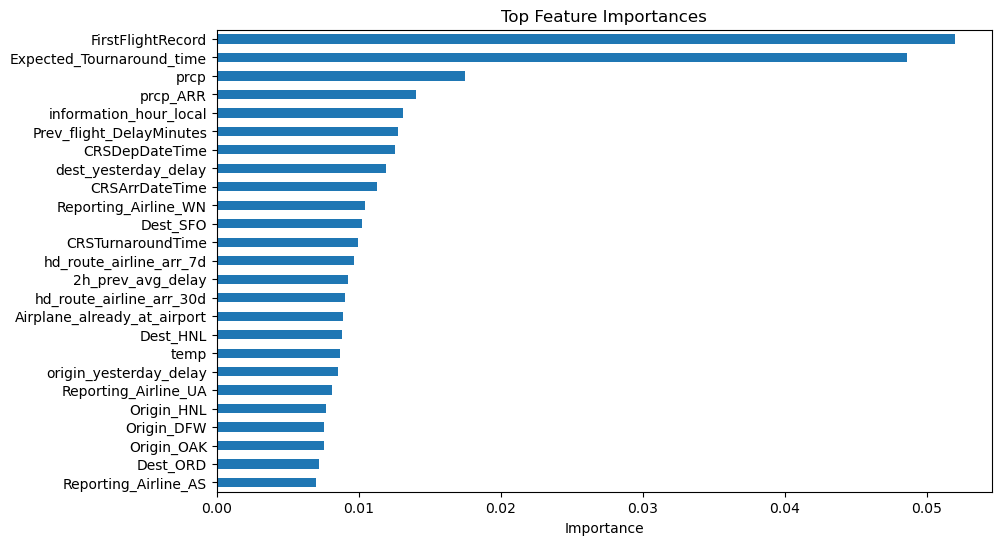

<bound method NDFrame.head of FirstFlightRecord            0.051985
Expected_Tournaround_time    0.048609
prcp                         0.017456
prcp_ARR                     0.014016
information_hour_local       0.013096
                               ...   
Origin_MSP                   0.003022
Origin_STL                   0.002997
Dest_SAN                     0.002529
Dest_HOU                     0.001633
has_prev_flight              0.000000
Length: 158, dtype: float32>

In [15]:
# get the feature importances for the model and plot them
feature_importances = get_feature_importances(model, feature_names=X_train.columns)
# plot the feature importances
plot_feature_importances(feature_importances, top_n=25)
display(feature_importances.head)

In [16]:
test_metrics = evaluate_classifier(model, X_test, y_test)
pd.Series(test_metrics, name=f'{MODEL_NAME}_test_metrics')

F1-macro: 0.3842


0    {'accuracy': 0.8449919197915636, 'balanced_acc...
1    [0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, ...
Name: xgboost_test_metrics, dtype: object

## 9. Final Test Evaluation

Only use the test set after choosing a model. This gives the honest final estimate for the report.


In [17]:
test_metrics = evaluate_classifier(model, X_test, y_test)
pd.Series(test_metrics, name=f'{MODEL_NAME}_test_metrics')


F1-macro: 0.3842


0    {'accuracy': 0.8449919197915636, 'balanced_acc...
1    [0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, ...
Name: xgboost_test_metrics, dtype: object

In [18]:
# Per-class report. Look especially at recall for medium_delay and large_delay.
classification_report_frame(model, X_test, y_test)


,precision,recall,f1-score,support
no_delay,0.879886,0.972982,0.924095,25613.000000
small_delay,0.254980,0.033490,0.059204,1911.000000
medium_delay,0.301273,0.144211,0.195055,1477.000000
large_delay,0.406731,0.320455,0.358475,1320.000000
accuracy,0.844992,0.844992,0.844992,0.844992
macro avg,0.460717,0.367785,0.384207,30321.000000
weighted avg,0.791717,0.844992,0.809448,30321.000000


## 10. Run The Whole Pipeline In One Cell

The cells above show each step. For actual experiments, use `run_training(...)`, which runs the same steps and saves outputs automatically.


Info: The following columns are in the dataset but not recorded in the feature engineering lists: {'total_flights_in_hour_ARR', 'flights_departing_in_hour_ARR', 'Unnamed: 0', 'total_flights_in_hour_DEP', 'flights_arriving_in_hour_ARR', 'rhum_ARR', 'rhum', 'flights_arriving_in_hour_DEP', 'flights_departing_in_hour_DEP', 'information_hour_local', 'hd_ground_crew_carrier_3d'}


c:\miniconda3\envs\imgP\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:42:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


F1-macro: 0.3696
F1-macro: 0.3888


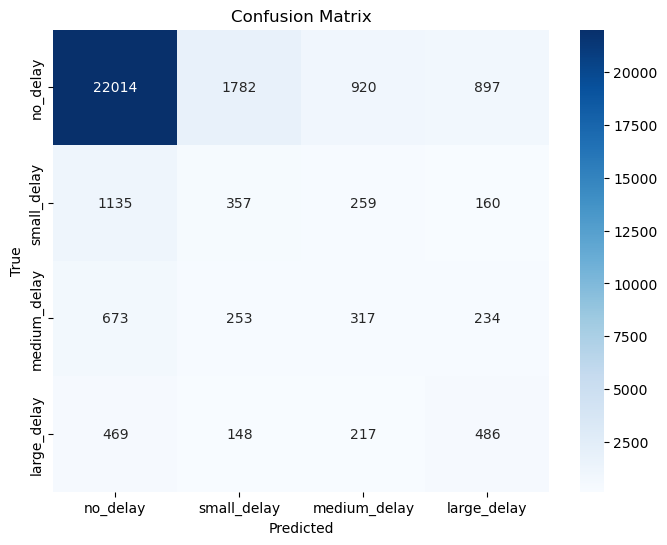

In [19]:
config = TrainingConfig(
    data_root=DATA_ROOT,
    input_path=INPUT_PATH,
    output_dir=OUTPUT_DIR,
    model_name=MODEL_NAME,
    delay_column=DELAY_COLUMN,
    target_column=TARGET_COLUMN,
    time_column=TIME_COLUMN,
    sample_frac=SAMPLE_FRAC,
    tune=False,
)

metrics,val_predictions,test_predictions = run_training(config)
pd.Series(metrics, name='pipeline_metrics')
# plot the confusion matrix for the pipeline model
plotConfusionMatrix(predictions=test_predictions, y_true=y_test)

## 11. Optional: Hyperparameter Tuning

Tuning tries multiple parameter combinations with `TimeSeriesSplit`. This can take a long time. Use it only after the simple training run works.


Info: The following columns are in the dataset but not recorded in the feature engineering lists: {'total_flights_in_hour_ARR', 'flights_departing_in_hour_ARR', 'Unnamed: 0', 'total_flights_in_hour_DEP', 'flights_arriving_in_hour_ARR', 'rhum_ARR', 'rhum', 'flights_arriving_in_hour_DEP', 'flights_departing_in_hour_DEP', 'information_hour_local', 'hd_ground_crew_carrier_3d'}
Fitting 3 folds for each of 3 candidates, totalling 9 fits


c:\miniconda3\envs\imgP\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:47:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


F1-macro: 0.3618
F1-macro: 0.3830


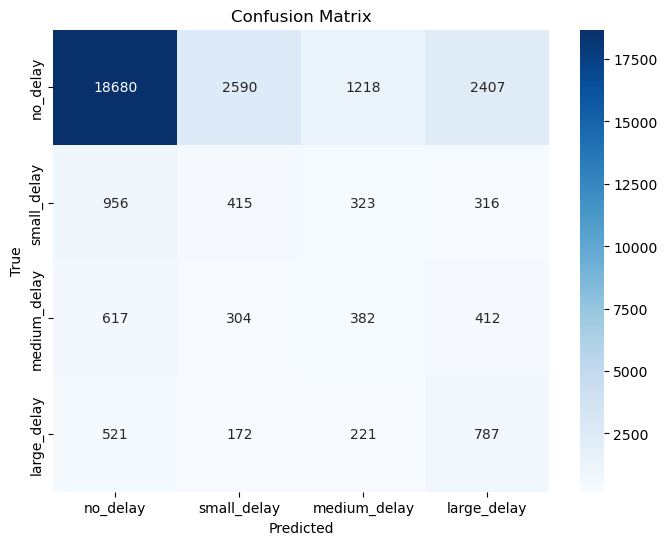

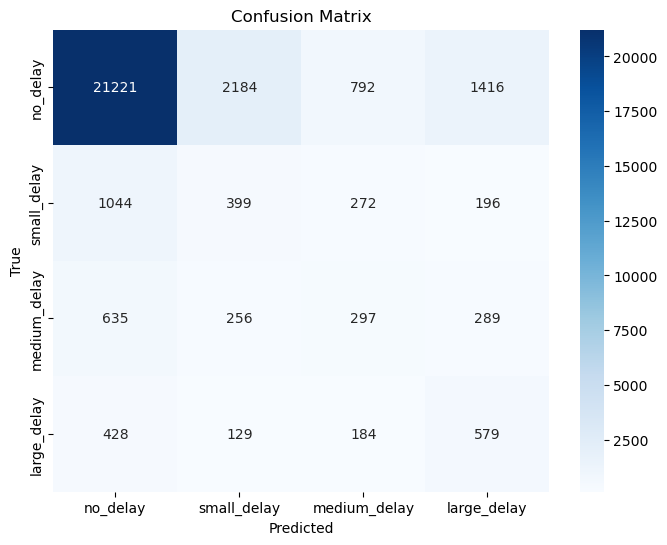

In [20]:
# Uncomment this cell when you are ready for a slower tuning run.
tuned_config = TrainingConfig(
    data_root=DATA_ROOT,
    input_path=INPUT_PATH,
    output_dir='outputs/training_notebook_tuned',
    model_name=MODEL_NAME,
    delay_column=DELAY_COLUMN,
    target_column=TARGET_COLUMN,
    time_column=TIME_COLUMN,
    sample_frac=SAMPLE_FRAC,
    tune=True,
    n_iter=3,
    cv_splits=3,
)
tuned_metrics,tuned_val_predictions,tuned_test_predictions = run_training(tuned_config)
pd.Series(tuned_metrics, name='tuned_pipeline_metrics')
# plot the confusion matrix for the tuned pipeline model
plotConfusionMatrix(predictions=tuned_val_predictions, y_true=y_val)
plotConfusionMatrix(predictions=tuned_test_predictions, y_true=y_test)

## 12. What To Report

For the university report, include:

- target class definitions
- chronological split dates
- class distribution
- baseline metrics
- final model metrics
- per-class precision and recall
- error analysis for `medium_delay` and `large_delay`

Accuracy alone is not enough because most flights are probably `no_delay`.
